# Phase 2: Building Machine Learning Models
## Logistic Regression

In this notebook, we will train the Logistic Regression first on our MinMax scaled data, and then completely separately on our Standard scaled data to compare the results.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

## Part 1: MinMax Scaled Dataset

### 1.1 Load the Data

In [2]:
data = pd.read_csv('Telco-Customer-Churn-MinMax.csv')
df = pd.DataFrame(data)
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,0.013889,0,1,0.11,0.003339,0,...,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,0.472222,1,0,0.38,0.217526,0,...,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,0.027778,1,1,0.35,0.012437,1,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,0.625000,0,0,0.24,0.211884,0,...,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,0.027778,1,1,0.52,0.017388,1,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,0.333333,1,1,0.66,0.229157,0,...,1,0,1,0,1,1,0,0,0,1
7039,0,0,1,1,1.000000,1,1,0.85,0.847766,0,...,0,0,1,0,1,1,0,1,0,0
7040,0,0,1,1,0.152778,0,1,0.11,0.039843,0,...,0,0,0,0,0,0,0,0,1,0
7041,1,1,1,0,0.055556,1,1,0.56,0.035237,1,...,0,0,0,0,0,0,0,0,0,1


### 1.2 Train-Test Split (Data Segregation)
We split the data: $80\%$ for training, $20\%$ for testing. `random_state=42` ensures reproducible results.

In [3]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training Data Size:", X_train.shape) 
print("Testing Data Size:", X_test.shape)

Training Data Size: (5634, 30)
Testing Data Size: (1409, 30)


### 1.3 Train the Model

In [4]:
model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### 1.4 Evaluate the Model

Accuracy Score: 0.8218594748048261

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.78      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



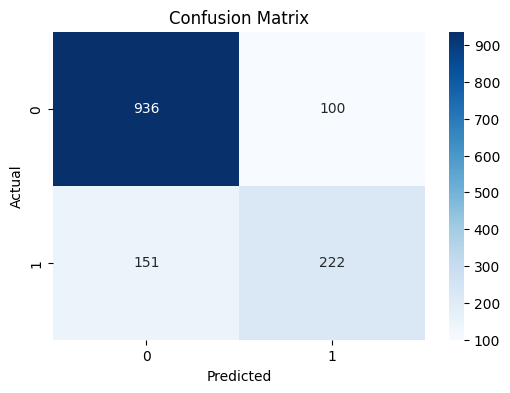

In [5]:
y_test_pred = model.predict(X_test)
print("Accuracy Score:", accuracy_score(y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))

cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6,4))
sb.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## Part 2: Standard Scaled Dataset

### 2.1 Load the Data

In [6]:
data = pd.read_csv('Telco-Customer-Churn-Standard.csv')
df = pd.DataFrame(data)
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,-1.277445,0,1,-1.172988,-0.992780,0,...,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,0.066327,1,0,-0.275697,-0.172179,0,...,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,-1.236724,1,1,-0.375396,-0.957927,1,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,0.514251,0,0,-0.740959,-0.193797,0,...,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,-1.236724,1,1,0.189564,-0.938956,1,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,-0.340876,1,1,0.654826,-0.127619,0,...,1,0,1,0,1,1,0,0,0,1
7039,0,0,1,1,1.613701,1,1,1.286253,2.242419,0,...,0,0,1,0,1,1,0,1,0,0
7040,0,0,1,1,-0.870241,0,1,-1.172988,-0.852925,0,...,0,0,0,0,0,0,0,0,1,0
7041,1,1,1,0,-1.155283,1,1,0.322496,-0.870572,1,...,0,0,0,0,0,0,0,0,0,1


### 2.2 Train-Test Split (Data Segregation)

In [7]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training Data Size:", X_train.shape) 
print("Testing Data Size:", X_test.shape)

Training Data Size: (5634, 30)
Testing Data Size: (1409, 30)


### 2.3 Train the Model

In [8]:
model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### 2.4 Evaluate the Model

Accuracy Score: 0.8218594748048261

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



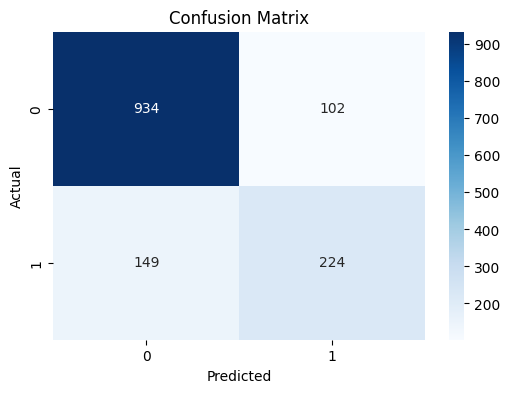

In [9]:
y_test_pred = model.predict(X_test)
print("Accuracy Score:", accuracy_score(y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))

cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6,4))
sb.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## Part 3: Mathematical Theory & Explanations

### 📊 Model Deep Dive: Logistic Regression

**What type of graph does it make?**
*   An **S-shaped curve** (the Sigmoid curve). Instead of shooting off into infinity like a straight line, it bends so that everybody is forced entirely between $0$ and $1$.

**When to use it?**
*   When you need to predict a **strict binary category** (Yes/No, $1/0$, Churn/No Churn). It is the absolute industry-standard baseline for Classification problems.

**Why use it?**
*   Unlike predicting hard categories, Logistic Regression outputs an exact **Probability** (e.g., "There is an $82\%$ chance this user churns"). This allows businesses to set custom thresholds based on risk.


### Logistic Regression (The Industry Baseline)
Logistic Regression squishes a straight line into an "S-shape" (the Sigmoid curve). This guarantees that every prediction falls strictly between $0$ and $1$, giving us a true **probability** of Churn.

**The Sigmoid Function:**
$$P(y=1|X) = \frac{1}{1 + e^{-z}}$$
*(where $z$ is the standard Linear Regression formula: $z = \beta_0 + \beta_1x_1 + \dots$)*

**The Internal Threshold:**
When we call `model.predict()`, Scikit-Learn automatically returns $1$ if the probability $\ge 0.5$, and $0$ if it is $< 0.5$.



## Part 4: The Fundamental Difference in Metrics
*   Use **Regression Metrics** (MAE, RMSE, $R^2$, Residuals) when your answer is a *continuous number* (Price: $\$250, \$599.99, \$10$). You measure the *distance* of the error.
*   Use **Classification Metrics** (Accuracy, Precision, Recall, Confusion Matrix) when your answer is a *strict category* (Churn: `Yes` or `No`). You measure the *count* of correct vs incorrect predictions. 

### Regression Metrics Explained (Predicting Continuous Numbers)
* **Mean Absolute Error (MAE):** The average absolute distance between the actual value and the predicted value. (e.g. "On average, our house price prediction was off by $\$5,000$").
* **Mean Squared Error (MSE):** The average of the *squared* distances. Squaring punishes the model heavily for making massive outliers/mistakes. 
* **Root Mean Squared Error (RMSE):** The square root of MSE. This brings the error back into the original units (e.g. "Dollars" instead of "Squared Dollars").
* **$R^2$ (R-Squared) Score:** This is the ultimate "goodness of fit" score. It tells us the percentage of the data's movement that is actually explained by our model.
  * $R^2 = 1 - \frac{Sum\ of\ Squared\ Residuals\ (SSR)}{Total\ Sum\ of\ Squares\ (SST)}$
  * **SSR (Sum of Squared Residuals):** The sum of the squared differences between the actual observed value ($y_i$) and the model's predicted value ($\hat{y}_i$). This measures the *unexplained* variance (the error of our line).
  * **SST (Total Sum of Squares):** The sum of the squared differences between the actual observed value ($y_i$) and the average/mean of all observed values ($\bar{y}$). This measures the *total variance* in the dataset (how spread out the data is from its own average).
* **Residuals:** The difference between the observed value and the predicted value. 
  $$Residual = y_i - \hat{y}_i$$

### Classification Metrics Explained (Predicting Strict Categories)
Because we are predicting strict categories (`1` or `0`), we use **Classification Metrics** to measure the *count* of correct vs. incorrect buckets.

**1. The Confusion Matrix**
The foundation of all classification metrics. It categorizes predictions into four absolute buckets:
* **True Positives (TP):** We predicted Churn ($1$), and they actually Churned ($1$).
* **True Negatives (TN):** We predicted No Churn ($0$), and they actually Didn't Churn ($0$).
* **False Positives (FP) [Type I Error]:** We predicted Churn ($1$), but they Didn't Churn ($0$). *(False Alarm)*
* **False Negatives (FN) [Type II Error]:** We predicted No Churn ($0$), but they actually Churned ($1$). *(Missed Opportunity)*

**2. Accuracy Score**
The percentage of total predictions the model got completely right.
$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$

**3. Precision (Quality of Positive Predictions)**
"Out of all the customers we *predicted* would churn, how many *actually* churned?"
$$Precision = \frac{TP}{TP + FP}$$

**4. Recall / Sensitivity (Quantity of Positive Predictions)**
"Out of all the customers who *actually* churned, how many did we successfully *find*?"
$$Recall = \frac{TP}{TP + FN}$$

**5. F1-Score**
The harmonic mean of Precision and Recall. It is the gold standard metric when your dataset is imbalanced.
$$F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}$$

### 📈 Visualization: Plotting the Sigmoid Curve

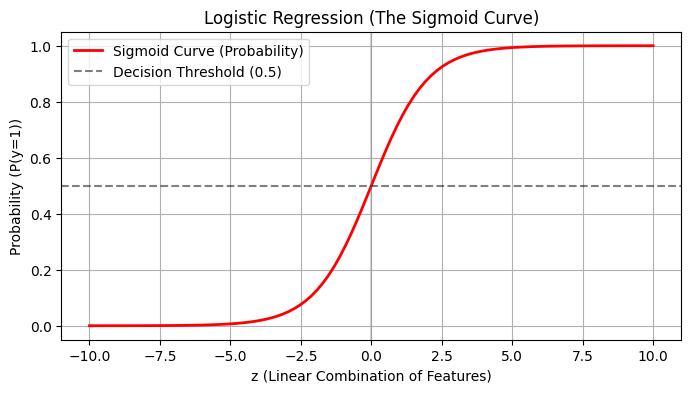

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Generate a range of values for z (our equation line)
z = np.linspace(-10, 10, 100)
y_sig = sigmoid(z)

plt.figure(figsize=(8, 4))
plt.plot(z, y_sig, color='red', linewidth=2, label='Sigmoid Curve (Probability)')
plt.axhline(0.5, color='black', linestyle='--', alpha=0.5, label='Decision Threshold (0.5)')
plt.axvline(0, color='gray', linestyle='-', alpha=0.3)
plt.title("Logistic Regression (The Sigmoid Curve)")
plt.xlabel("z (Linear Combination of Features)")
plt.ylabel("Probability (P(y=1))")
plt.legend()
plt.grid(True)
plt.show()